### This notebook was created to help us visualize all of the potential features that we're considering using for variable star identification and classification

### It is mostly just an exploration of the distribution of the various datasets that we're working with

### After looking through this data, we've come to the conclusion that many of the summary statistics calculated in DP1 diaObject were calculated using flagged values and highly erroneous values

### This led us to create our own summary statistics using the Forced Source on DiaObject table (where we filtered data to exclude possibly erroneous points)

In [3]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lsst.rsp import get_tap_service

**Read in the data**

In [4]:
# load in csv with all feature columns of interest and at least 4 nDiaSources
df = pd.read_csv('variablestar_filtered.csv')

In [5]:
pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)
df

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm
0,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.446000,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,NaN,-589.070678,759.578197,NaN,-5.891703e+02,1.353681e+06,NaN,NaN,0.013990,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.000000,2661.922705,-282.140698,NaN,36.384200,174.148667,NaN,-0.308456,-6.606807,NaN,-1.784346,-0.947541
1,579575256428052807,6.028941,-72.575914,4831.474609,-25320.785156,-179.425217,NaN,30822.791670,12747.179363,1.633590e-12,5837.170000,4387.010000,NaN,67.365384,14.667108,0.0,21795.000000,1060.870000,1.0,2.0,6.0,9,47,RRLyrae,RR*,True,4831.475098,113.860986,7076.623047,4831.475098,-19501.644287,4804.219238,4831.475098,-39117.147852,-18428.811035,NaN,3957.027722,915.011223,NaN,3.956014e+03,4.433660e+06,NaN,NaN,-2.390770,94495.656250,73381.914062,83378.773438,NaN,33545.521350,11401.191513,18.961470,19.236027,19.097361,-0.274557,0.138666,-0.135891,0.000000,39231.008838,18542.672021,inf,5837.170000,877.402000,NaN,-1.217292,-71.044525,NaN,-0.339954,-0.864105
2,579575256428052608,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,0.000000e+00,23896.600000,3197.090000,NaN,43.766055,21.391475,0.0,7401.710000,1991.170000,1.0,10.0,4.0,15,47,RRLyrae,RR*,True,3551.469238,38994.763281,19067.249121,3551.469238,-5791.553955,-6033.679688,3551.469238,-13202.357617,-8143.472314,NaN,-2118.933673,-2688.534241,NaN,3.390524e+06,1.824429e+06,NaN,1.306770,1.916990,48699.910156,71115.671875,60267.218750,NaN,20358.782126,30144.760459,19.681180,19.270087,19.449797,0.411093,-0.179710,0.231382,0.000000,52197.120898,47138.235596,NaN,2655.177778,1065.696667,NaN,8.899072,-22.049331,NaN,-0.543214,-0.300869
3,579575256428052935,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,9.085750e+03,12708.900000,5545.660000,91.219314,33.282176,24.862708,23838.8,6484.890000,1207.250000,2.0,8.0,4.0,14,47,RRLyrae,RR*,True,20898.193750,21044.452930,4280.432800,-556.765625,-8482.533936,2385.933716,-22011.726953,-15661.032666,-29527.344727,7927.920396,2113.773047,3448.378869,7.930342e+03,4.964968e+06,1.101634e+06,NaN,1.102430,-1.981840,61150.265625,54424.007812,54046.925781,33382.845358,15685.787582,19297.797066,19.434004,19.560524,19.568073,-0.126520,-0.007549,-0.134068,42909.920703,36705.485596,50571.797656,9085.750000,1815.557143,1848.553333,-13.710925,-3.835548,-4.067157,-0.262875,-0.540284,-0.447263
4,579575874903343585,6.531026,-72.410982,1884.615479,-1872.704224,-1940.932861,17228.444619,10182.526231,7189.145685,1.940270e+04,21548.700000,3130.320000,48.349704,25.344947,11.968275,16024.6,10336.200000,1457.330000,8.0,24.0,11.0,43,47,RRLyrae,RR*,True,22099.233691,13363.509180,

In [96]:
df.isna().sum()

diaObjectId                  0
ra                           0
dec                          0
g_psfFluxMean              416
r_psfFluxMean               14
                          ... 
r_psfFluxSigma_norm         23
i_psfFluxSigma_norm        172
g_scienceFluxSigma_norm    458
r_scienceFluxSigma_norm     23
i_scienceFluxSigma_norm    172
Length: 68, dtype: int64

**Create separate dataframes for each class**

In [6]:
df_rrl = df[df['Class'] == 'RRLyrae']
df_ceph = df[df['Class'] == 'Cepheid']
df_lpv = df[df['Class'] == 'LPV']

In [7]:
print(df_rrl.shape)
print(df_ceph.shape)
print(df_lpv.shape)

(354, 68)
(16, 68)
(180, 68)


### Create data visualizations to understand the distribution for the features we aim to use for our ML model
1. This will effectively help us determine which thesholds can give us the ability to see what is likely to be a variable star
2. We can then use this for unsupervised approach to cluster different groups

In [2]:
def plotFeature(Feature, df, df_rrl, df_ceph, df_lpv, printSummary, plotOutliers):
    feature_all = df[Feature].dropna()
    feature_rrl = df_rrl[Feature].dropna()
    feature_ceph = df_ceph[Feature].dropna()
    feature_lpv = df_lpv[Feature].dropna()

    plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],
            labels=['RRL', 'Ceph', 'LPV', 'All'], showfliers=plotOutliers) # don't show the extreme outliers

    plt.title('Boxplot for feature ' + str(Feature) + ' by class and all')
    plt.ylabel(Feature)
    plt.grid(True)
    plt.show

    if printSummary:
        # summary statistics for each
        print(str(feature_all.describe()) + '\n')
        print(str(feature_rrl.describe()) + '\n')
        print(str(feature_ceph.describe()) + '\n')
        print(str(feature_lpv.describe()) + '\n')

**r_psfFluxMean**

count       536.000000
mean       1199.450385
std       26092.256342
min     -103542.789062
25%       -2221.958435
50%         -23.945270
75%        1963.818909
max      501611.468750
Name: r_psfFluxMean, dtype: float64

count       349.000000
mean        849.885220
std       15178.358109
min     -103542.789062
25%       -1980.411133
50%          -2.566885
75%        1994.219849
max      188277.781250
Name: r_psfFluxMean, dtype: float64

count       15.000000
mean    -15987.586479
std      28906.159398
min     -87457.179688
25%      -9328.842163
50%      -2665.816162
75%      -1021.798508
max        521.847412
Name: r_psfFluxMean, dtype: float64

count       172.000000
mean       3407.611986
std       39518.138785
min      -27179.855469
25%       -2445.960938
50%         -14.606016
75%        2046.406036
max      501611.468750
Name: r_psfFluxMean, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


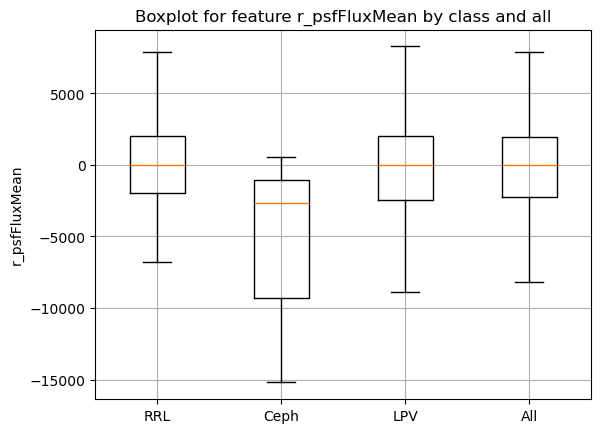

In [100]:
plotFeature('r_psfFluxMean', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFluxSigma**

count       527.000000
mean       7744.792244
std       33182.509260
min          11.479609
25%         309.809575
50%        1763.409584
75%        5311.115628
max      561544.600481
Name: r_psfFluxSigma, dtype: float64

count       345.000000
mean       6042.931491
std       37175.041638
min          11.479609
25%         214.022522
50%         565.893968
75%        2094.854736
max      561544.600481
Name: r_psfFluxSigma, dtype: float64

count        15.000000
mean      32785.758429
std       74764.128413
min         318.945709
25%        1540.686174
50%        2997.549805
75%       14066.875510
max      283995.259318
Name: r_psfFluxSigma, dtype: float64

count      167.000000
mean      9011.423781
std       9453.995395
min        101.701981
25%       3456.247845
50%       5563.436769
75%      11800.665402
max      56793.356955
Name: r_psfFluxSigma, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


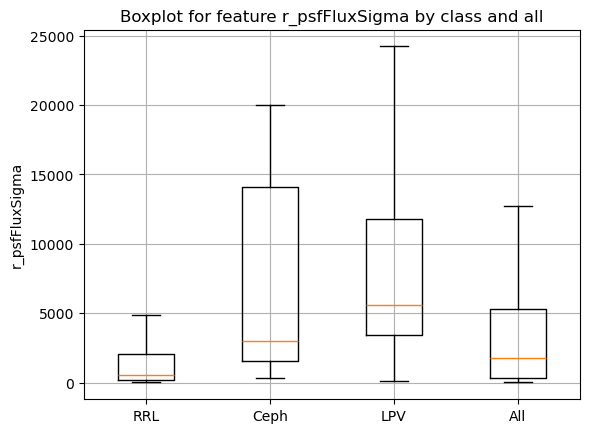

In [40]:
plotFeature('r_psfFluxSigma', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFfluxChi2**

count    5.360000e+02
mean     3.448555e+04
std      5.281599e+05
min      0.000000e+00
25%      7.257633e+00
50%      3.092790e+02
75%      1.923517e+03
max      1.179310e+07
Name: r_psfFluxChi2, dtype: float64

count    3.490000e+02
mean     4.733614e+04
std      6.531943e+05
min      0.000000e+00
25%      4.040270e+00
50%      3.084140e+01
75%      8.299490e+02
max      1.179310e+07
Name: r_psfFluxChi2, dtype: float64

count        15.000000
mean      78100.112757
std      190373.833542
min           9.931850
25%         650.011993
50%        2051.949951
75%       16423.435010
max      597997.000000
Name: r_psfFluxChi2, dtype: float64

count      172.000000
mean      4607.223907
std       9068.939166
min          0.000000
25%        450.811500
50%       1523.245000
75%       4449.987500
max      62414.800000
Name: r_psfFluxChi2, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


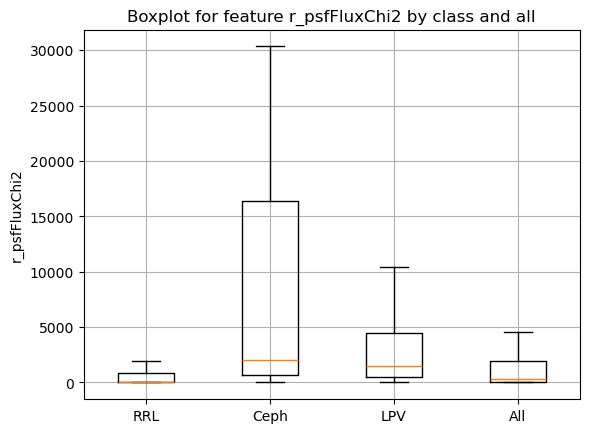

In [41]:
plotFeature('r_psfFluxChi2', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_red_chi2 (we calculated this one)**

count    529.000000
mean            inf
std             NaN
min        0.004638
25%        3.207760
50%       50.443733
75%      246.578667
max             inf
Name: r_red_chi2, dtype: float64

count    346.000000
mean            inf
std             NaN
min        0.004638
25%        1.438116
50%       12.783157
75%      172.811304
max             inf
Name: r_red_chi2, dtype: float64

count       15.000000
mean      7637.191378
std      19462.018442
min          3.310617
25%        113.466540
50%        374.496667
75%       3344.649618
max      74749.625000
Name: r_red_chi2, dtype: float64

count    168.000000
mean            inf
std             NaN
min        0.267213
25%       44.901550
50%      122.455915
75%      362.162679
max             inf
Name: r_red_chi2, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


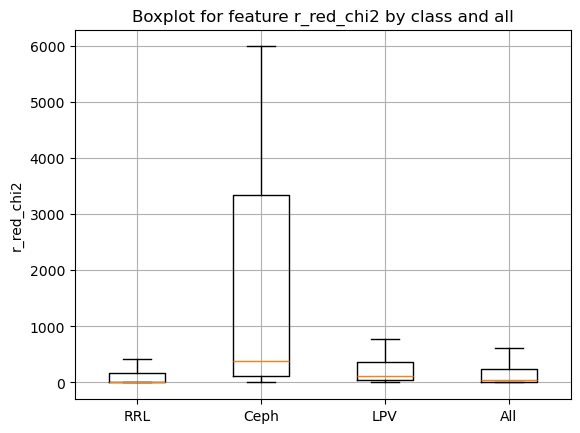

In [92]:
plotFeature('r_red_chi2', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFluxStetsonJ**

count    527.000000
mean       9.667436
std       21.479716
min       -0.997678
25%        0.650199
50%        4.959733
75%       11.228720
max      326.814580
Name: r_psfFluxStetsonJ, dtype: float64

count    345.000000
mean       8.408543
std       24.220288
min       -0.997678
25%        0.089871
50%        2.216997
75%        9.313409
max      326.814580
Name: r_psfFluxStetsonJ, dtype: float64

count     15.000000
mean      31.743161
std       39.323429
min        0.683836
25%        7.849803
50%       14.072437
75%       42.168134
max      109.712154
Name: r_psfFluxStetsonJ, dtype: float64

count    167.000000
mean      10.285293
std        8.257022
min       -0.845260
25%        4.823994
50%        7.982201
75%       13.108757
max       50.079817
Name: r_psfFluxStetsonJ, dtype: float64



/tmp/ipykernel_22881/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


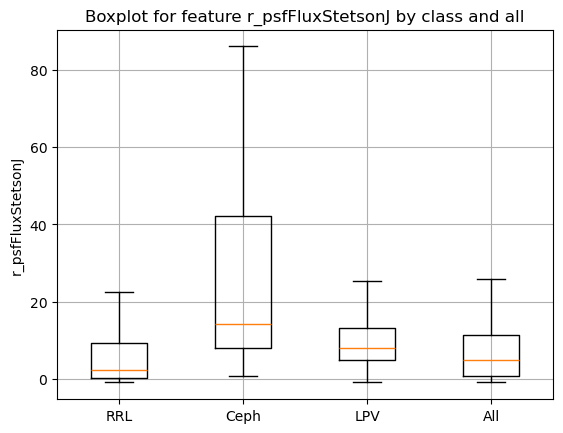

In [8]:
plotFeature('r_psfFluxStetsonJ', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFLuxMAD**

count       536.000000
mean       3327.446234
std       21840.862678
min           0.000000
25%         129.937748
50%         428.355011
75%        2193.402500
max      472285.000000
Name: r_psfFluxMAD, dtype: float64

count       349.000000
mean       2971.977436
std       26690.244646
min           0.000000
25%          91.280602
50%         181.123993
75%         519.263000
max      472285.000000
Name: r_psfFluxMAD, dtype: float64

count       15.000000
mean      4811.657210
std       9862.261319
min        139.266006
25%        246.620496
50%        992.853027
75%       2618.725037
max      36426.000000
Name: r_psfFluxMAD, dtype: float64

count      172.000000
mean      3919.280222
std       5825.885853
min          0.000000
25%       1548.717500
50%       2359.065000
75%       3557.677500
max      51048.000000
Name: r_psfFluxMAD, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


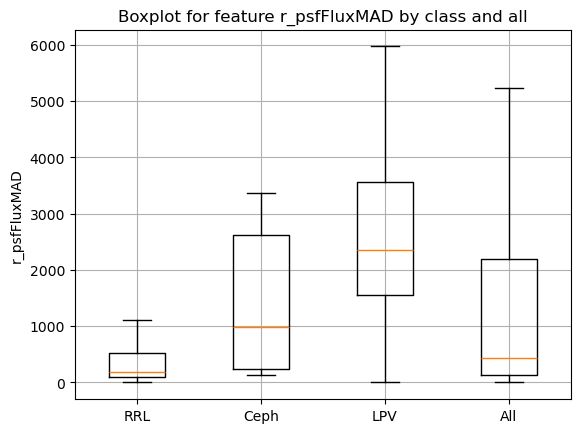

In [43]:
plotFeature('r_psfFluxMAD', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFLuxNdata**

count    536.000000
mean       8.992537
std        7.744515
min        1.000000
25%        4.000000
50%        5.000000
75%       14.000000
max       69.000000
Name: r_psfFluxNdata, dtype: float64

count    349.000000
mean       6.303725
std        6.729547
min        1.000000
25%        4.000000
50%        4.000000
75%        5.000000
max       69.000000
Name: r_psfFluxNdata, dtype: float64

count    15.000000
mean      8.266667
std       5.338093
min       4.000000
25%       4.500000
50%       7.000000
75%       9.500000
max      24.000000
Name: r_psfFluxNdata, dtype: float64

count    172.000000
mean      14.511628
std        6.907482
min        1.000000
25%        9.000000
50%       16.500000
75%       20.000000
max       34.000000
Name: r_psfFluxNdata, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


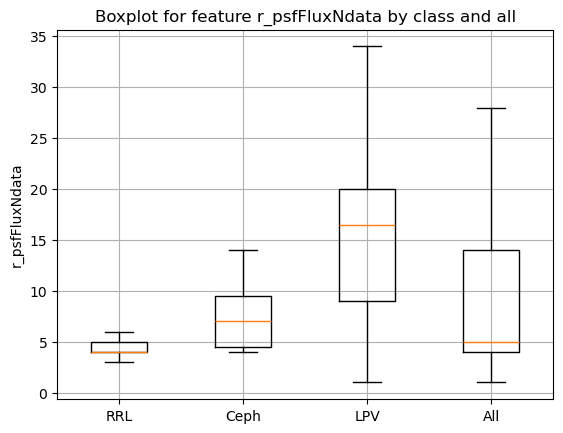

In [44]:
plotFeature('r_psfFluxNdata', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFluxLinear**

count    5.270000e+02
mean    -9.324457e+03
std      3.194610e+05
min     -2.719562e+06
25%     -4.178860e+03
50%     -1.354148e+02
75%      1.896915e+03
max      2.849754e+06
Name: r_psfFluxLinearSlope, dtype: float64

count    3.450000e+02
mean    -2.553935e+04
std      3.413420e+05
min     -2.719562e+06
25%     -4.265470e+04
50%     -2.367628e+02
75%      6.651847e+03
max      2.631775e+06
Name: r_psfFluxLinearSlope, dtype: float64

count    1.500000e+01
mean     1.462973e+04
std      3.837137e+05
min     -8.582503e+05
25%     -2.144237e+03
50%     -3.196224e+02
75%      4.481578e+03
max      1.143505e+06
Name: r_psfFluxLinearSlope, dtype: float64

count    1.670000e+02
mean     2.202180e+04
std      2.606231e+05
min     -8.787537e+05
25%     -9.621471e+02
50%     -4.544127e+00
75%      8.960240e+02
max      2.849754e+06
Name: r_psfFluxLinearSlope, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


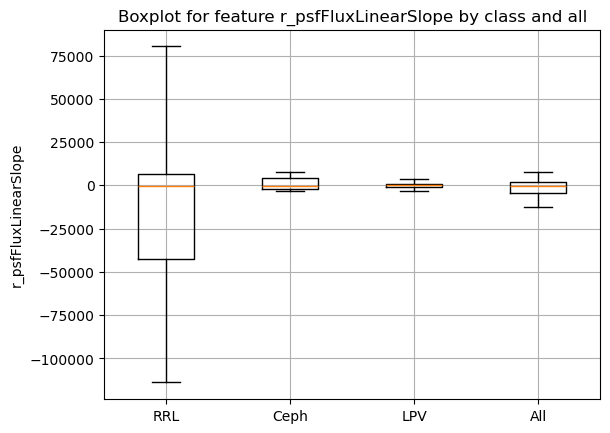

In [46]:
plotFeature('r_psfFluxLinearSlope', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFluxMaxSlope**

count    5.270000e+02
mean     1.331090e+07
std      1.044510e+08
min     -1.940151e+06
25%      3.656917e+05
50%      1.268145e+06
75%      7.280813e+06
max      1.889099e+09
Name: r_psfFluxMaxSlope, dtype: float64

count    3.450000e+02
mean     1.129415e+07
std      1.279109e+08
min     -1.940151e+06
25%      2.446508e+05
50%      6.815740e+05
75%      1.596822e+06
max      1.889099e+09
Name: r_psfFluxMaxSlope, dtype: float64

count    1.500000e+01
mean     4.908760e+06
std      5.912473e+06
min      2.294648e+04
25%      1.243841e+06
50%      1.963301e+06
75%      7.362454e+06
max      2.132270e+07
Name: r_psfFluxMaxSlope, dtype: float64

count    1.670000e+02
mean     1.823192e+07
std      2.496057e+07
min     -9.472391e+02
25%      6.259663e+06
50%      1.094516e+07
75%      1.956318e+07
max      1.607765e+08
Name: r_psfFluxMaxSlope, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


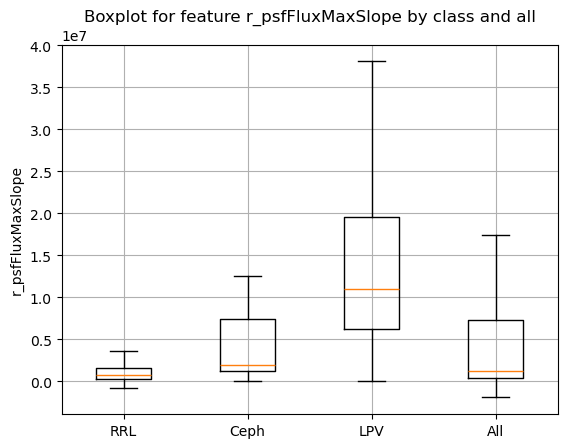

In [47]:
plotFeature('r_psfFluxMaxSlope', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFluxSkew**

count    509.000000
mean       0.102452
std        1.212436
min       -3.217120
25%       -0.784738
50%        0.102017
75%        1.073780
max        2.575180
Name: r_psfFluxSkew, dtype: float64

count    330.000000
mean       0.159910
std        1.260618
min       -2.443330
25%       -0.778441
50%        0.195835
75%        1.211767
max        2.575180
Name: r_psfFluxSkew, dtype: float64

count    15.000000
mean      0.081145
std       1.367744
min      -2.988080
25%      -0.709055
50%       0.327596
75%       0.989313
max       1.998810
Name: r_psfFluxSkew, dtype: float64

count    164.000000
mean      -0.011215
std        1.092424
min       -3.217120
25%       -0.815763
50%       -0.007812
75%        0.850460
max        2.441010
Name: r_psfFluxSkew, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


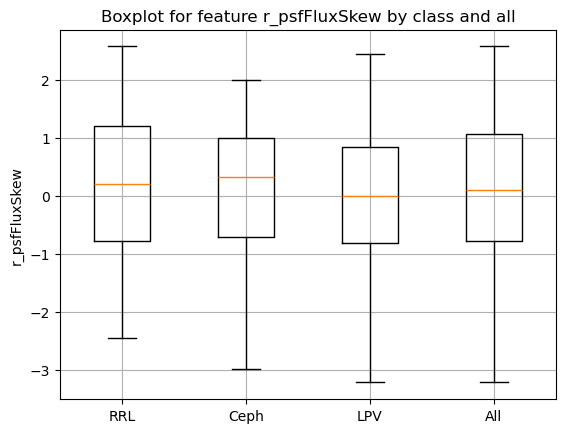

In [48]:
plotFeature('r_psfFluxSkew', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**rmag**

count    536.000000
mean      20.397844
std        2.102386
min       15.103407
25%       18.925999
50%       21.072395
75%       21.413528
max       28.816599
Name: rmag, dtype: float64

count    349.000000
mean      21.357065
std        1.586710
min       15.705632
25%       21.048510
50%       21.278463
75%       21.525806
max       28.816599
Name: rmag, dtype: float64

count    15.000000
mean     20.485645
std       2.340358
min      16.016489
25%      19.553098
50%      20.730337
75%      21.282630
max      25.706972
Name: rmag, dtype: float64

count    172.000000
mean      18.443861
std        1.593027
min       15.103407
25%       17.695768
50%       18.102237
75%       19.132941
max       23.911396
Name: rmag, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


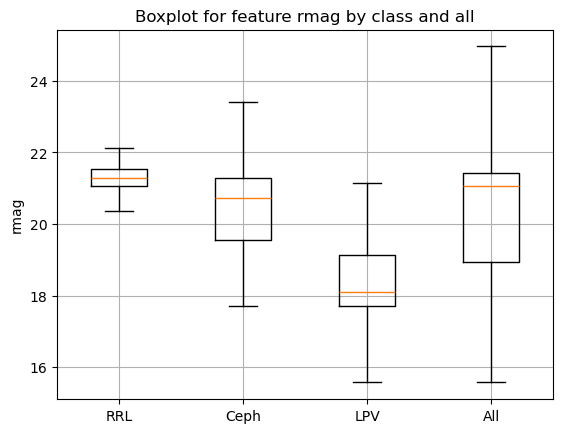

In [51]:
plotFeature('rmag', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_i (color)**

count    434.000000
mean       0.788307
std        1.385239
min       -1.648106
25%       -0.007193
50%        0.267912
75%        1.061447
max        7.529546
Name: r_i, dtype: float64

count    272.000000
mean       0.419691
std        1.243451
min       -1.648106
25%       -0.134694
50%        0.103097
75%        0.282300
max        7.529546
Name: r_i, dtype: float64

count    15.000000
mean      0.671762
std       1.303927
min      -0.420157
25%       0.077080
50%       0.166465
75%       0.393977
max       4.493876
Name: r_i, dtype: float64

count    147.000000
mean       1.482264
std        1.385117
min       -0.819955
25%        0.689866
50%        1.071743
75%        1.588819
max        6.861168
Name: r_i, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


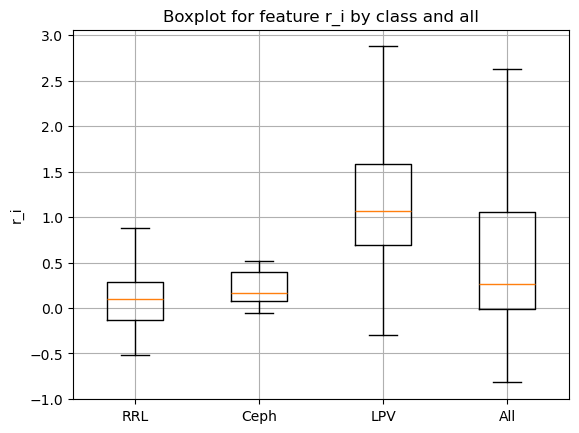

In [53]:
plotFeature('r_i', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**amp_r**

count    5.360000e+02
mean     1.820034e+04
std      8.301032e+04
min      0.000000e+00
25%      5.601877e+02
50%      3.644375e+03
75%      1.344693e+04
max      1.586853e+06
Name: amp_r, dtype: float64

count    3.490000e+02
mean     1.414635e+04
std      9.671252e+04
min      0.000000e+00
25%      4.158966e+02
50%      1.018986e+03
75%      4.539268e+03
max      1.586853e+06
Name: amp_r, dtype: float64

count        15.000000
mean      67130.285091
std      145629.397446
min         698.108936
25%        3394.058125
50%        7847.054059
75%       26768.307843
max      534382.756250
Name: amp_r, dtype: float64

count       172.000000
mean      22159.045664
std       22982.944820
min           0.000000
25%        7655.469719
50%       14147.494756
75%       28752.454803
max      126764.702344
Name: amp_r, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


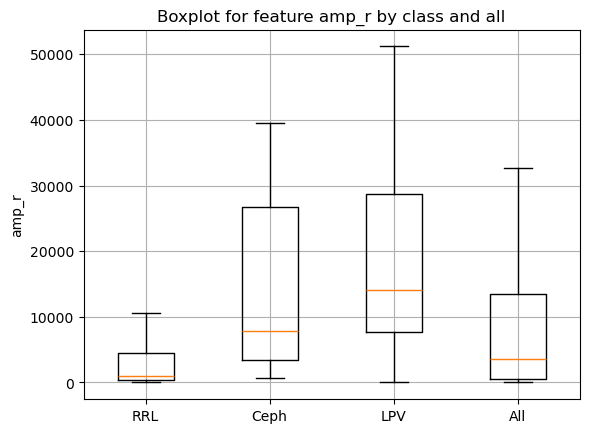

In [66]:
plotFeature('amp_r', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_psfFLuxMean**

count       536.000000
mean       1199.450385
std       26092.256342
min     -103542.789062
25%       -2221.958435
50%         -23.945270
75%        1963.818909
max      501611.468750
Name: r_psfFluxMean, dtype: float64

count       349.000000
mean        849.885220
std       15178.358109
min     -103542.789062
25%       -1980.411133
50%          -2.566885
75%        1994.219849
max      188277.781250
Name: r_psfFluxMean, dtype: float64

count       15.000000
mean    -15987.586479
std      28906.159398
min     -87457.179688
25%      -9328.842163
50%      -2665.816162
75%      -1021.798508
max        521.847412
Name: r_psfFluxMean, dtype: float64

count       172.000000
mean       3407.611986
std       39518.138785
min      -27179.855469
25%       -2445.960938
50%         -14.606016
75%        2046.406036
max      501611.468750
Name: r_psfFluxMean, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


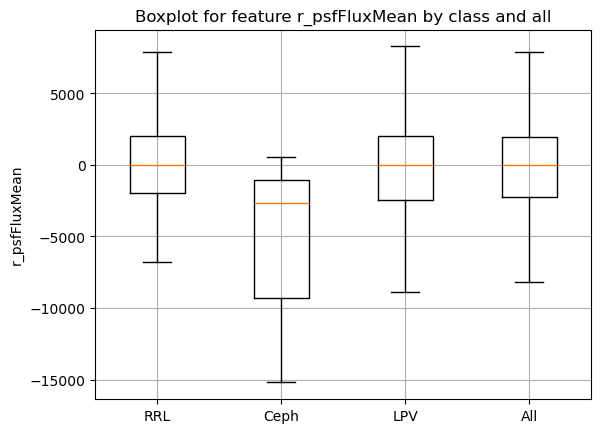

In [79]:
plotFeature('r_psfFluxMean', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_scienceFluxSigma_norm**

count    527.000000
mean      -0.784877
std        0.826829
min       -3.468842
25%       -1.400765
50%       -0.777717
75%       -0.452365
max        2.074571
Name: r_scienceFluxSigma_norm, dtype: float64

count    345.000000
mean      -0.926987
std        0.835587
min       -3.468842
25%       -1.512437
50%       -0.986971
75%       -0.590952
max        1.936832
Name: r_scienceFluxSigma_norm, dtype: float64

count    15.000000
mean     -0.501230
std       0.793405
min      -2.013218
25%      -0.783299
50%      -0.595485
75%      -0.376985
max       1.289915
Name: r_scienceFluxSigma_norm, dtype: float64

count    167.000000
mean      -0.516775
std        0.738056
min       -1.956728
25%       -0.911148
50%       -0.562715
75%       -0.317462
max        2.074571
Name: r_scienceFluxSigma_norm, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


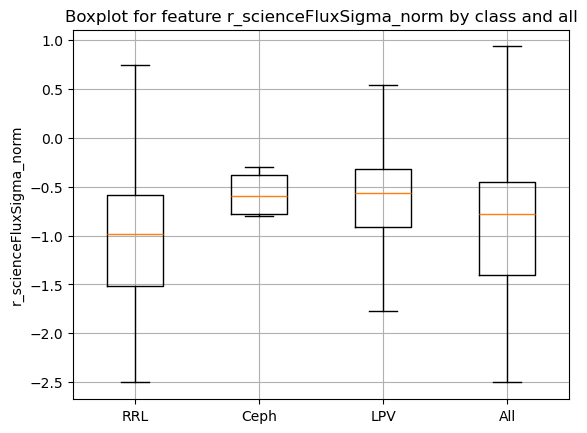

In [110]:
plotFeature('r_scienceFluxSigma_norm', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_scienceFluxSigma**

count       527.000000
mean      27574.531466
std       63468.422264
min           2.824284
25%         545.267219
50%        3437.183396
75%       30671.861376
max      719300.030267
Name: r_scienceFluxSigma, dtype: float64

count       345.000000
mean       9280.074654
std       57812.679797
min           2.824284
25%         350.199345
50%        1370.616171
75%        3538.063984
max      719300.030267
Name: r_scienceFluxSigma, dtype: float64

count        15.000000
mean      37793.524181
std       84493.538484
min         178.057365
25%        3722.122033
50%        7628.830685
75%       13782.731637
max      326067.428747
Name: r_scienceFluxSigma, dtype: float64

count       167.000000
mean      64450.595595
std       56238.822780
min         406.682205
25%       29354.131959
50%       56622.386266
75%       82896.998756
max      453300.612929
Name: r_scienceFluxSigma, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


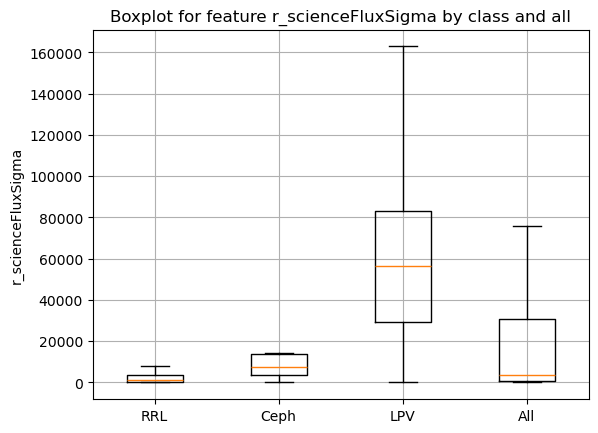

In [88]:
plotFeature('r_scienceFluxSigma', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)

**r_scicenFluxMean**

count    5.360000e+02
mean     1.341673e+05
std      3.287325e+05
min      1.079843e+01
25%      9.876185e+03
50%      1.352204e+04
75%      9.774200e+04
max      3.300936e+06
Name: r_scienceFluxMean, dtype: float64

count    3.490000e+02
mean     3.702105e+04
std      1.640075e+05
min      1.079843e+01
25%      8.905894e+03
50%      1.118445e+04
75%      1.382280e+04
max      1.895602e+06
Name: r_scienceFluxMean, dtype: float64

count    1.500000e+01
mean     1.510197e+05
std      3.655897e+05
min      1.893264e+02
25%      1.117382e+04
50%      1.852956e+04
75%      5.491632e+04
max      1.423653e+06
Name: r_scienceFluxMean, dtype: float64

count    1.720000e+02
mean     3.298140e+05
std      4.632791e+05
min      9.895588e+02
25%      8.072705e+04
50%      2.085013e+05
75%      3.031746e+05
max      3.300936e+06
Name: r_scienceFluxMean, dtype: float64



/tmp/ipykernel_30083/1697950006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_rrl, feature_ceph, feature_lpv, feature_all],


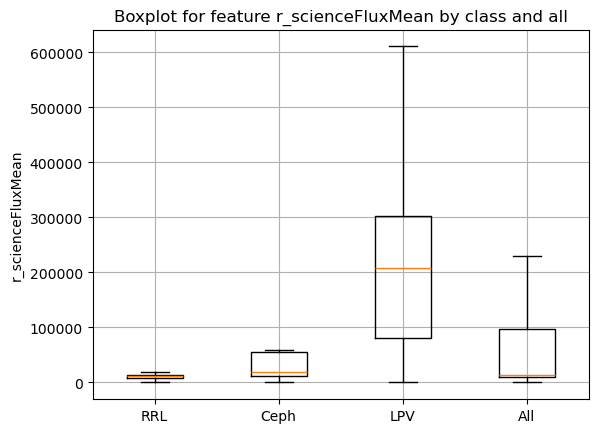

In [89]:
plotFeature('r_scienceFluxMean', df, df_rrl, df_ceph, df_lpv, printSummary=True, plotOutliers=False)